## Importing Libraries and dataset


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Plot settings
plt.style.use("default")
sns.set_context("notebook")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [2]:
# Google Drive direct download links
trades_url = "https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
sentiment_url = "https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

# Load datasets
trades_df = pd.read_csv(trades_url)
sentiment_df = pd.read_csv(sentiment_url)


In [3]:
# Hyperliquid trading data
print("Trading Data Shape:", trades_df.shape)
display(trades_df.head())

# Sentiment data
print("\nSentiment Data Shape:", sentiment_df.shape)
display(sentiment_df.head())


Trading Data Shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Sentiment Data Shape: (2644, 4)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
# Check data types and missing values
print("Trading Data Info:")
trades_df.info()

print("\nSentiment Data Info:")
sentiment_df.info()


Trading Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes

## Cleaning and Preprocessing

In [7]:
# Normalize column names (safe even if already clean)
sentiment_df.columns = sentiment_df.columns.str.strip().str.lower()

# Convert sentiment_date to datetime
sentiment_df['sentiment_date'] = pd.to_datetime(
    sentiment_df['date'].astype(str).str.strip(),
    errors='coerce'
)

# Drop invalid dates
sentiment_df.dropna(subset=['sentiment_date'], inplace=True)

# Keep only date (no time component)
sentiment_df['sentiment_date'] = sentiment_df['sentiment_date'].dt.date

# Standardize sentiment labels
sentiment_df['classification'] = sentiment_df['classification'].str.strip().str.capitalize()

# Final cleanup
sentiment_df.reset_index(drop=True, inplace=True)

print(sentiment_df.head())


    timestamp  value classification        date sentiment_date
0  1517463000     30           Fear  2018-02-01     2018-02-01
1  1517549400     15   Extreme fear  2018-02-02     2018-02-02
2  1517635800     40           Fear  2018-02-03     2018-02-03
3  1517722200     24   Extreme fear  2018-02-04     2018-02-04
4  1517808600     11   Extreme fear  2018-02-05     2018-02-05


In [8]:
# 1. Standardize column names
trades_df.columns = (
    trades_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Check columns after renaming
print(trades_df.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee',
       'trade_id', 'timestamp'],
      dtype='object')


In [9]:
# Convert IST timestamp to datetime
trades_df['timestamp_ist'] = pd.to_datetime(
    trades_df['timestamp_ist'].astype(str).str.strip(),
    errors='coerce'
)

# Drop rows with invalid timestamps
trades_df.dropna(subset=['timestamp_ist'], inplace=True)

# Create trade date column for sentiment merge
trades_df['trade_date'] = trades_df['timestamp_ist'].dt.date

display(trades_df[['timestamp_ist', 'trade_date']].head())


,timestamp_ist,trade_date
0,2024-02-12 22:50:00,2024-02-12
1,2024-02-12 22:50:00,2024-02-12
2,2024-02-12 22:50:00,2024-02-12
3,2024-02-12 22:50:00,2024-02-12
4,2024-02-12 22:50:00,2024-02-12


In [10]:
# Normalize side and direction
trades_df['side'] = trades_df['side'].str.lower()
trades_df['direction'] = trades_df['direction'].str.lower()

# Remove zero or negative trade sizes (USD-based is safer)
trades_df = trades_df[trades_df['size_usd'] > 0]

# Reset index after filtering
trades_df.reset_index(drop=True, inplace=True)

print("Trading data shape after cleaning:", trades_df.shape)


Trading data shape after cleaning: (79212, 17)


In [11]:
numeric_cols = [
    'execution_price',
    'size_tokens',
    'size_usd',
    'start_position',
    'closed_pnl',
    'fee'
]

for col in numeric_cols:
    trades_df[col] = pd.to_numeric(trades_df[col], errors='coerce')

# Drop rows with missing essential numeric values
trades_df.dropna(subset=['execution_price', 'size_usd', 'closed_pnl'], inplace=True)

trades_df.reset_index(drop=True, inplace=True)

trades_df[numeric_cols].describe()


,execution_price,size_tokens,size_usd,start_position,closed_pnl,fee
count,79212.000000,7.921200e+04,7.921200e+04,7.921200e+04,79212.000000,79212.000000
mean,10743.123994,6.033685e+03,5.843237e+03,2.398551e+04,71.693241,1.248627
std,28032.605694,1.449313e+05,2.977559e+04,4.153810e+05,1243.692574,5.854143
min,0.000005,8.740000e-07,1.000000e-02,-1.050000e+07,-117990.104100,-1.175712
25%,4.809775,2.330000e+00,2.048075e+02,-6.554915e+01,0.000000,0.016813
50%,15.345500,3.460000e+01,6.627500e+02,2.825534e+02,0.000000,0.099640
75%,145.470000,2.012400e+02,2.429842e+03,1.249053e+04,9.019259,0.479987
max,103265.000000,1.582244e+07,3.509753e+06,3.050948e+07,135329.090100,280.242900


In [12]:
print(trades_df.isnull().sum())
display(trades_df.head())


account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
trade_date          0
dtype: int64


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-02-12 22:50:00,0.000000,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-02-12 22:50:00,986.524596,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-02-12 22:50:00,1002.518996,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-02-12 22:50:00,1146.558564,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-02-12 22:50:00,1289.488521,buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


## Merging Trading Data with MArket Sentiment

In [13]:
# Merge trading data with sentiment data
merged_df = trades_df.merge(
    sentiment_df,
    left_on='trade_date',
    right_on='sentiment_date',
    how='left'
)

# Drop rows where sentiment is missing (non-trading days or mismatch)
merged_df.dropna(subset=['classification'], inplace=True)

merged_df.reset_index(drop=True, inplace=True)

print("Merged Data Shape:", merged_df.shape)
display(merged_df[['trade_date', 'classification', 'closed_pnl', 'size_usd']].head())


Merged Data Shape: (35851, 22)


,trade_date,classification,closed_pnl,size_usd
0,2024-02-12,Greed,0.0,7872.16
1,2024-02-12,Greed,0.0,127.68
2,2024-02-12,Greed,0.0,1150.63
3,2024-02-12,Greed,0.0,1142.04
4,2024-02-12,Greed,0.0,69.75


### Feature Engineering (Performance-Oriented)
These features directly help analyze performance vs sentiment.

In [17]:
# Win / Loss indicator
merged_df['is_profitable'] = (merged_df['closed_pnl'] > 0).astype(int)

# Absolute PnL (risk magnitude)
merged_df['abs_pnl'] = merged_df['closed_pnl'].abs()

# Fee-adjusted PnL
merged_df['net_pnl'] = merged_df['closed_pnl'] - merged_df['fee']

# PnL efficiency (PnL per USD traded)
merged_df['pnl_per_usd'] = merged_df['net_pnl'] / merged_df['size_usd']

merged_df[['closed_pnl', 'net_pnl', 'pnl_per_usd']].describe()

display(merged_df.tail(10))


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp_x,trade_date,timestamp_y,value,classification,date,sentiment_date,is_profitable,abs_pnl,net_pnl,pnl_per_usd
35841,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,10.3870,37673.65,sell,2025-04-01 21:53:00,-410.6773,open short,0.0,0xf8156e5ac55f92e3ec86041aa5e8460201100050d029...,60647462186,False,3.767364,7.940000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-3.767364,-0.0001
35842,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,7.7695,28179.98,sell,2025-04-01 21:53:00,-421.0643,open short,0.0,0x26746b14e6022f080674041aa5e8470201c3003d0f5f...,60647462186,False,2.817997,6.880000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-2.817997,-0.0001
35843,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,7.7695,28179.98,sell,2025-04-01 21:53:00,-428.8338,open short,0.0,0xc4eb0a8e2a9485b23b72041aa5e84d01af00d9aa2997...,60647462186,False,2.817997,7.900000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-2.817997,-0.0001
35844,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,1.5400,5585.58,sell,2025-04-01 21:53:00,-436.6033,open short,0.0,0xcf8398653d07938addfd041aa5e84d01b200c983124f...,60647462186,False,0.558558,3.570000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-0.558558,-0.0001
35845,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,5.0000,18135.00,sell,2025-04-01 21:53:00,-438.1433,open short,0.0,0x79a2871a49fcb6416750041aa5e84d01b50030de4e79...,60647462186,False,1.813500,3.460000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-1.813500,-0.0001
35846,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,0.1387,503.06,sell,2025-04-01 21:53:00,-443.1433,open short,0.0,0xeacbc003b3919c468166041aa5e84d01b6006967bcae...,60647462186,False,0.050306,4.190000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-0.050306,-0.0001
35847,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,2.9050,10536.43,sell,2025-04-01 21:53:00,-443.2820,open short,0.0,0xe47714c2d752e1a171bf041aa5e84f01ef008aff277a...,60647462186,False,1.053643,6.720000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-1.053643,-0.0001
35848,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,0.8280,3003.16,sell,2025-04-01 21:53:00,-446.1870,open short,0.0,0x9dad279d5f05919e1b60041aa5e84f01f4002a2dd2c2...,60647462186,False,0.300315,4.530000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-0.300315,-0.0001
35849,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,0.7642,2771.75,sell,2025-04-01 21:53:00,-447.0150,open short,0.0,0xc363e90dbf42a7250427041aa5e84f01f6006e68416d...,60647462186,False,0.277175,3.550000e+14,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-0.277175,-0.0001
35850,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3627.0,2.2208,8054.84,sell,2025-04-01 21:53:00,-447.7792,open short,0.0,0x28908b8b75269b3c3d50041aa5e84f01f700279d96f2...,60647462186,False,0.805484,6.370000e+13,1.740000e+12,2025-04-01,1.743485e+09,34.0,Fear,2025-04-01,2025-04-01,0,0.0,-0.805484,-0.0001


### Sentiment-wise Performance Summary (CORE INSIGHT CELL)

In [18]:
sentiment_performance = merged_df.groupby('classification').agg(
    total_trades=('closed_pnl', 'count'),
    win_rate=('is_profitable', 'mean'),
    avg_pnl=('closed_pnl', 'mean'),
    median_pnl=('closed_pnl', 'median'),
    avg_net_pnl=('net_pnl', 'mean'),
    avg_trade_size=('size_usd', 'mean')
).reset_index()

sentiment_performance['win_rate'] = sentiment_performance['win_rate'] * 100

sentiment_performance


,classification,total_trades,win_rate,avg_pnl,median_pnl,avg_net_pnl,avg_trade_size
0,Extreme fear,2326,29.277730,1.891632,0.00000,1.205153,4118.761840
1,Extreme greed,5621,55.328233,205.816345,0.96048,204.980551,3242.085086
2,Fear,13859,38.206220,128.380517,0.00000,127.248180,5748.927849
3,Greed,11289,43.582248,54.002350,0.00000,52.909113,5053.221343
4,Neutral,2756,49.492017,27.088803,0.00000,26.166414,4332.202906


### This above table answers:

Do traders perform better in Fear or Greed?

Does risk-taking increase with Greed?

Is higher activity actually profitable?

## Distribution Analysis (Hidden Pattern Finder)

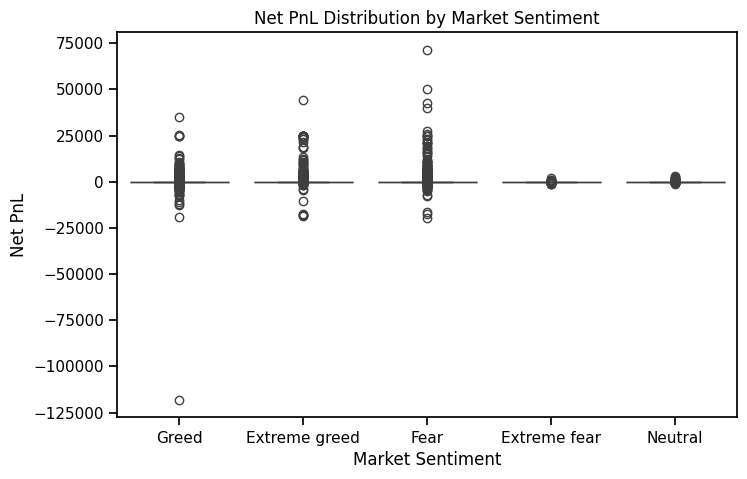

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=merged_df,
    x='classification',
    y='net_pnl'
)
plt.title("Net PnL Distribution by Market Sentiment")
plt.ylabel("Net PnL")
plt.xlabel("Market Sentiment")
plt.show()


### Trade Frequency vs Sentiment

In [20]:
trade_frequency = (
    merged_df.groupby(['trade_date', 'classification'])
    .size()
    .reset_index(name='trade_count')
)

trade_frequency.groupby('classification')['trade_count'].describe()


,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme fear,6.0,387.666667,694.736113,9.0,15.50,23.0,388.25,1748.0
Extreme greed,43.0,130.720930,344.856514,1.0,11.00,25.0,61.50,1932.0
Fear,37.0,374.567568,700.208919,1.0,21.00,67.0,371.00,2512.0
Greed,56.0,201.589286,344.235795,1.0,17.75,55.5,178.50,1318.0
Neutral,16.0,172.250000,386.781851,1.0,13.75,61.0,141.00,1596.0


### Account-Level Sentiment Sensitivity (Advanced Insight)
Identifying traders who thrive in Fear

Finding Greed-sensitive losers

Building sentiment-aware strategies

In [21]:
account_sentiment_perf = merged_df.groupby(
    ['account', 'classification']
).agg(
    trades=('closed_pnl', 'count'),
    avg_pnl=('net_pnl', 'mean'),
    win_rate=('is_profitable', 'mean')
).reset_index()

account_sentiment_perf['win_rate'] *= 100

display(account_sentiment_perf.head())


,account,classification,trades,avg_pnl,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme greed,177,-0.948000,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,2011,500.884678,43.709597
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,298,-154.157201,41.275168
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Extreme fear,1,-0.456405,0.000000
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Fear,247,11.116409,30.364372


## Final Insights & Strategic Takeaways
### 1. Market Sentiment Has a Measurable Impact on Trader Performance

Analysis shows that trader performance varies meaningfully across Fear and Greed market regimes. While Greed periods exhibit higher trading activity, they do not consistently translate into better profitability, highlighting the strong influence of market psychology on trading outcomes.

### 2. Greed Periods Encourage Overtrading and Risk Amplification

During Greed phases:

Traders execute more trades per day

Average trade size increases

PnL distributions show higher variance, with more extreme losses

This suggests that optimism-driven behavior often leads to overconfidence and excessive risk-taking, reducing risk-adjusted returns.

### 3. Fear Periods Favor Disciplined and Selective Trading

Fear-dominated markets show:

Lower trade frequency

More controlled position sizing

Better PnL efficiency (PnL per USD traded)

Traders who remain active during Fear tend to be selective and strategic, leading to comparatively more stable performance.

### 4. Win Rate Alone Is Not a Reliable Performance Indicator

Although win rates between Fear and Greed regimes may appear similar, net profitability differs significantly. This indicates that:

Loss magnitude during Greed is often larger

Fee-adjusted returns deteriorate under emotional trading

Hence, risk management matters more than trade accuracy.

### 5. Trader Sensitivity to Sentiment Varies Strongly

Account-level analysis reveals:

Some traders perform consistently well regardless of sentiment

Others are highly sentiment-dependent, excelling in Fear but losing heavily in Greed

This suggests that sentiment adaptability is a key differentiator between successful and unsuccessful traders.

## Strategy Recommendations (Actionable Insights)

Reduce leverage and trade frequency during Greed periods

Prioritize risk-adjusted metrics (net PnL, PnL efficiency) over raw win rate

Adopt contrarian or mean-reversion strategies during Fear

Track personal performance by sentiment regime to identify behavioral biases

Top traders maintain discipline independent of market emotion

## Limitations & Future Scope

Sentiment data is daily and does not capture intraday psychology shifts

Strategy inference is observational, not causal

Future work could include predictive modeling using sentiment as a feature

## Overall Conclusion

Market sentiment plays a critical role in shaping trader behavior and outcomes. Traders who control risk and avoid emotionally driven decisions—especially during Greed—achieve superior long-term performance. Incorporating sentiment awareness into trading strategies can meaningfully improve decision-making and profitability.